In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ritwikb3/heart-disease-statlog/Heart_disease_statlog.csv


# ***Loading Dataset and Checking it in Various ways***
This function reads our CSV data file and converts it into a structured table called a DataFrame which we name df.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/ritwikb3/heart-disease-statlog/Heart_disease_statlog.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


***This function just check null values and provide us some of null values in each column***

In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

***This function just give us information about each column how many values they have or which datatype is contained in them or is there any null***

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    int64  
 1   sex       270 non-null    int64  
 2   cp        270 non-null    int64  
 3   trestbps  270 non-null    int64  
 4   chol      270 non-null    int64  
 5   fbs       270 non-null    int64  
 6   restecg   270 non-null    int64  
 7   thalach   270 non-null    int64  
 8   exang     270 non-null    int64  
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    int64  
 11  ca        270 non-null    int64  
 12  thal      270 non-null    int64  
 13  target    270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB


***This function is used to describe our data into different statistics term and it is great for detecting outliers or other source that can make our data prediction worse***

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,2.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,0.585185,0.670370,1.822222,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,0.959140,0.497827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
50%,55.000000,1.000000,2.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,2.000000,3.000000,3.000000,1.000000


***This function is used to show if our dataset conatin duplicates or not***

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# ***Visualizing Feature Distributions Using Histograms***
***• In this step, we want to look at how the data in each column is spread out. Instead of plotting every single graph one by one manually we use a simple loop to automate it.***
***• for col in columns:: This loop goes through every single feature name in our list like age,sex,cp and so on.***
***• sns.histplot(df[col], kde=True): This creates a histogram bar chart for the current column. Setting kde=True draws a smooth trend line over the bars to show us the shape of the data curve cleanly.***
***• plt.title(...): This automatically labels the top of each graph with its column name so we know exactly what we are looking at***.



# ***What the graphs tell us:***

***1.Continuous Data (like age,trestbps,chol,thalach): These graphs look like bells or smooth hills. This shows us that most patients fall into a middle range, with a few extreme values on the far left or right sides.***
***2.Categorical & Binary Data (like sex,fbs,target): These graphs show separate vertical blocks because the data only has specific values (like 0 and 1 or 0 to 3). For example the target histogram shows us our dataset is pretty evenly balanced between healthy patients (0) and heart disease patients (1).***


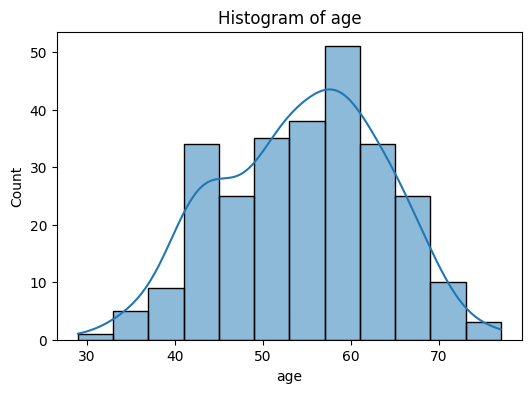

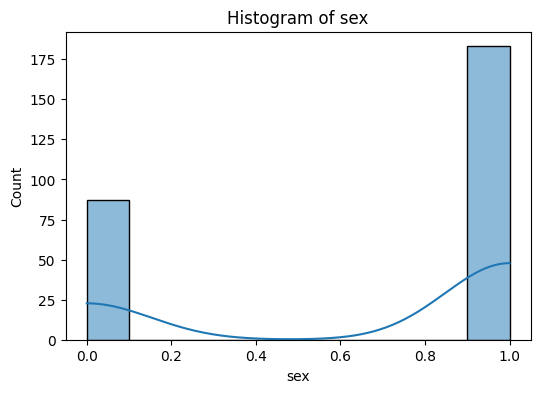

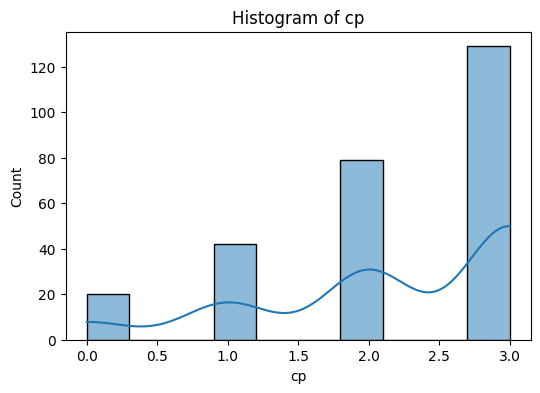

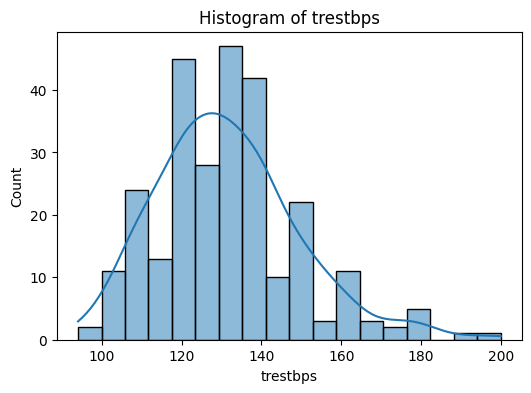

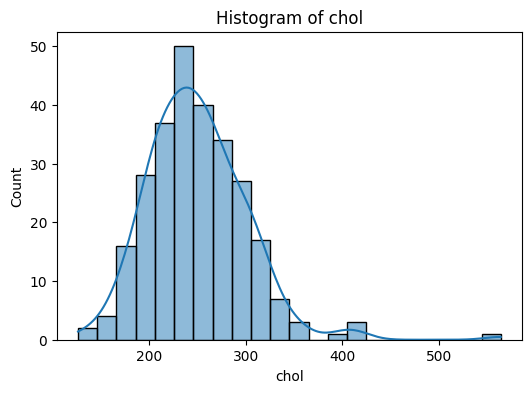

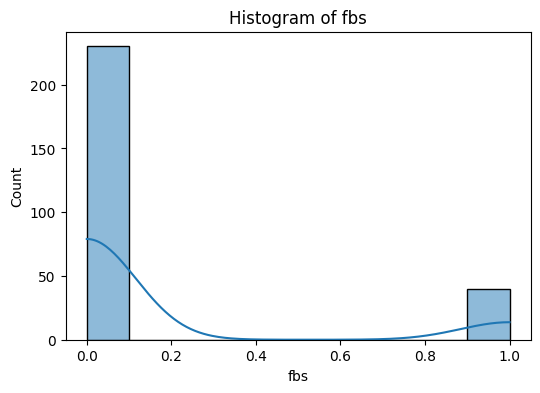

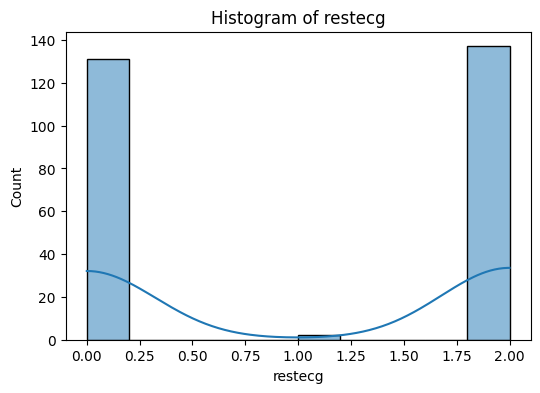

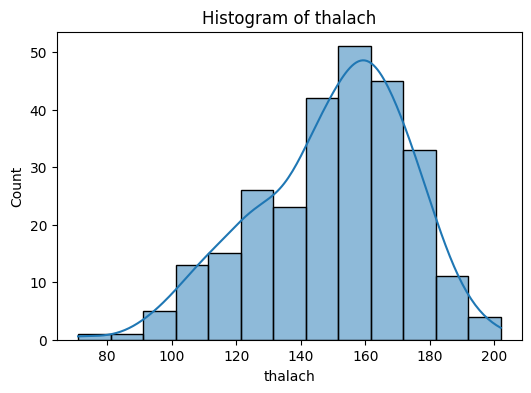

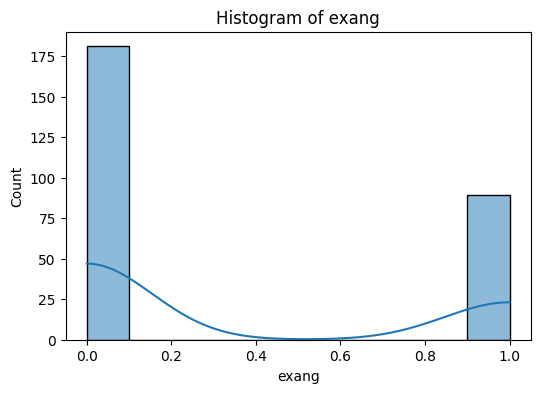

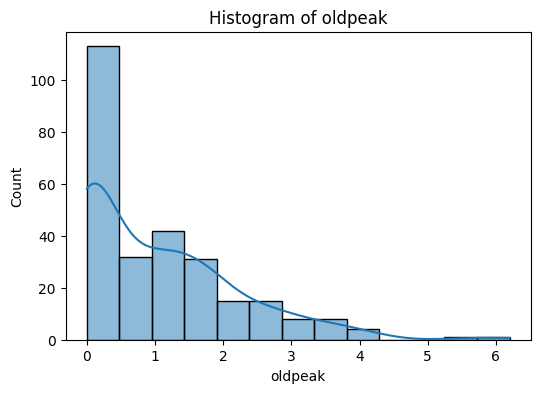

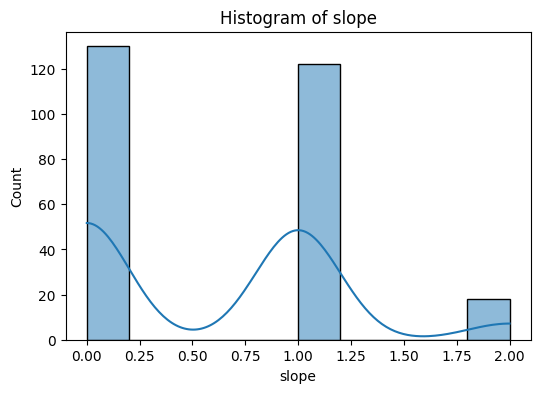

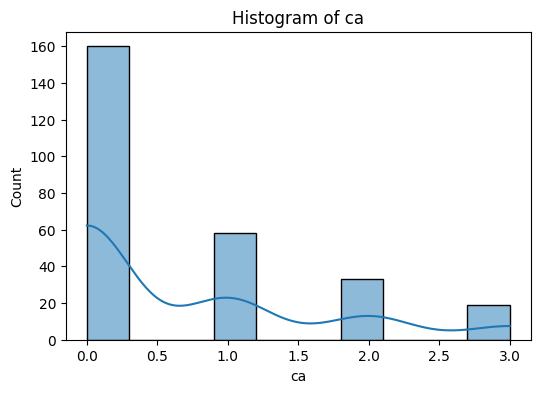

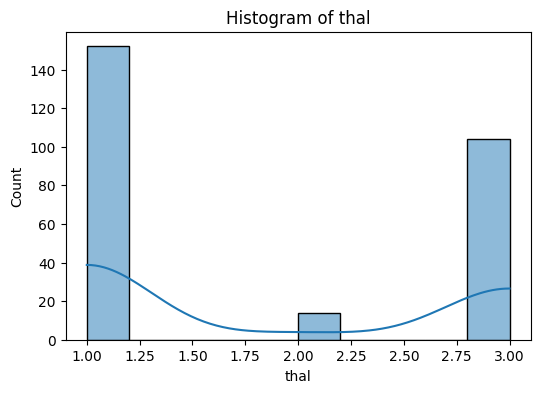

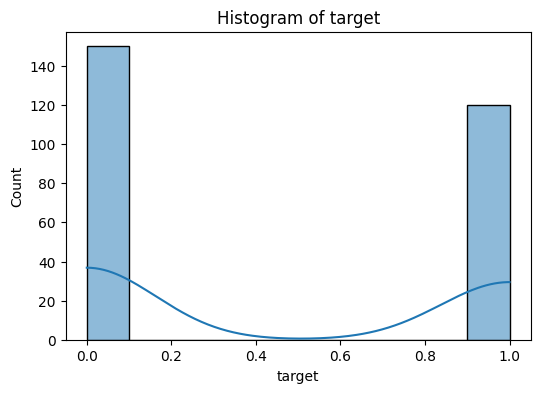

In [8]:
columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
for col in columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram of {col}")

# ***Finding Relationships Between Features Using a Heatmap***

***1.df.corr(): This calculates a correlation score between every single pair of columns in our dataset. The scores always fall between -1 and 1.***
***1.1.A score close to 1 means a strong positive relationship (as one number goes up, the other goes up).***
***1.2.A score close to -1 means a strong negative relationship (as one number goes up, the other drops).***
***1.3.A score near 0 means there is no real linear relationship between them.***


***2.sns.heatmap(..., cmap='coolwarm', annot=True): This builds the actual visual chart. Setting cmap='coolwarm' colors the highest positive correlations in bright red and the strong negative correlations in dark blue. Setting annot=True prints the exact number inside each box so it is easy to read.***


***3.plt.tight_layout() and plt.show(): These clean up the margins so no labels get cut off and cleanly render the final image on the screen.***

# ***Quick Data Insight from output:-***
***If you look at the very bottom row labeled target, you can see exactly which features matter most for making predictions. Features like thal (0.52) and ca (0.46) have strong red tones, showing they are highly related to heart disease. On the other hand, thalach (-0.42) is deep blue, meaning lower maximum heart rates are consistently seen in positive target cases.***

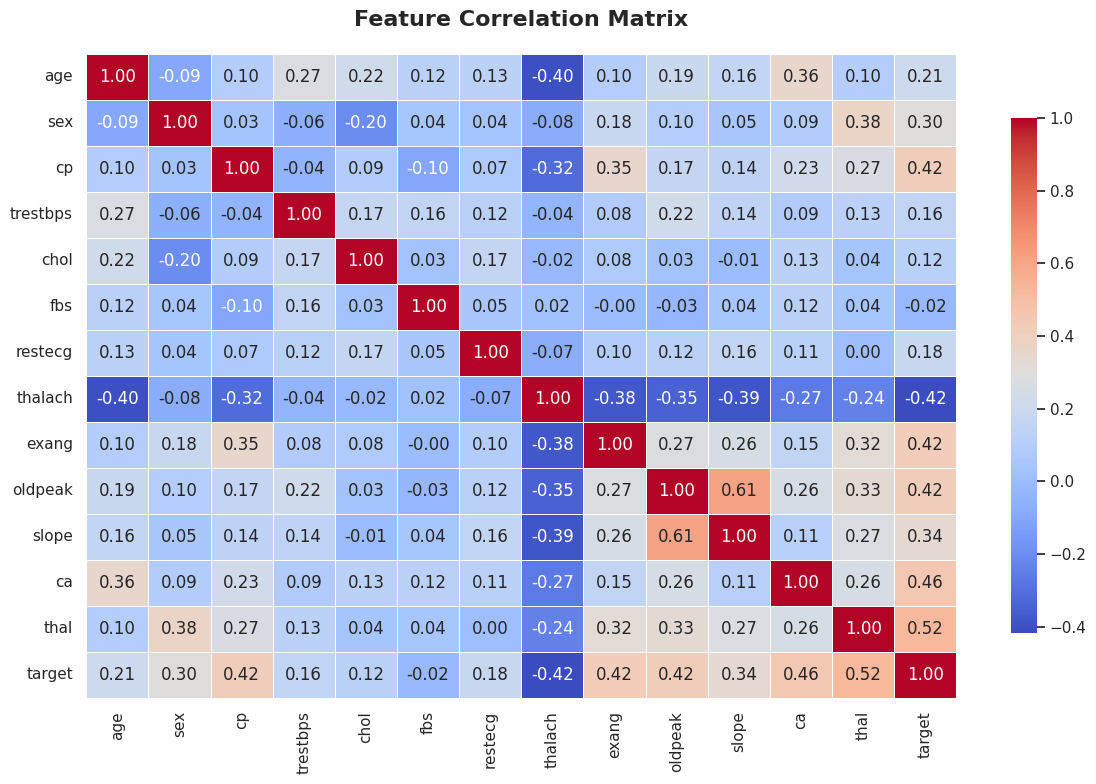

In [9]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(), annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5,cbar_kws={"shrink": .8})

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# ***Importing Machine Learning Libraries***

***StandardScaler: This tool rescales our continuous numbers (like age and cholesterol) so they all fall into a similar, small range. This stops columns with large numbers from taking over the model.***

 
***train_test_split: This splits our dataset into two parts: a Training set to teach our model, and a Testing set (20% of the data) to see how smart the model is on data it hasn't seen before.***


***LogisticRegression: This is our actual machine learning model algorithm. It is excellent for binary classification tasks, which means predicting between exactly two choices (0 or 1).***



***Pipeline: A pipeline lets us chain our preprocessing steps and our model together into a single object. This keeps our code clean and prevents mistakes.***



***ColumnTransformer: This allows us to target specific columns for specific transformations (like scaling only certain features while leaving others alone).
accuracy_score & classification_report: These are evaluation tools that will count how many right and wrong guesses our model makes so we can see its final score.***


In [10]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,classification_report

# ***Splitting the Data and Setting Up the Pipeline***

***X = df[col_features] and y = df['target']: We separate our data into two parts. X contains all our input features (like age, sex, and blood pressure), while y holds the target column that we want the model to learn how to predict.***


***train_test_split(...): This divides our data. It gives 80% of the rows to the training sets (X_train, y_train) to build the model, and saves 20% of the rows for the testing sets (X_test, y_test) to check the model's performance later. Setting random_state=42 ensures that the shuffle is exactly the same every time we rerun the cell.***


***ColumnTransformer(...): This creates our data processor. We tell it to apply our scaling pipeline (std_scale_pipeline) to all of our non-binary columns (like age, thalach, chol, etc.) to get them onto the same numerical scale.***


***Remainder='passthrough': This tells the processor to leave our binary 0 and 1 columns (like sex, fbs, and exang) exactly as they are without scaling them.***


***final_pipeline = Pipeline(...): This glues our steps together into one single workflow. It ensures that whenever data passes through, it first gets scaled by our preprocessor and then immediately goes straight into our LogisticRegression machine learning model.***

In [11]:
col_features=["age","sex","cp","thal","trestbps","chol","slope","ca","oldpeak","fbs","restecg","thalach","exang"]
X=df[col_features]
y=df["target"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

std_scale_pipeline=Pipeline(steps=[("std_scaler",StandardScaler())])
preprocessor = ColumnTransformer(
    transformers=[
        ("Scale_All_Numeric", std_scale_pipeline, [
            "age", "thalach", "chol", "oldpeak", "trestbps", "cp", "thal", "slope", "ca"
        ])
    ],
    remainder='passthrough'
)
final_pipeline=Pipeline(steps=[("Std Scaling ", preprocessor),("ml_model", LogisticRegression(C=0.5,max_iter=1000))])

# ***Training the Model and Checking the Evaluation Report***
***Now that our pipeline is ready, it is time to train our machine learning model on our training data and see how well it performs on our hidden test set.***

***1.final_pipeline.fit(X_train, y_train): This line trains our model. It automatically takes our training features, scales them, and passes them to the Logistic Regression model so it can learn the patterns of heart disease.***

***2.final_pipeline.predict(X_test): Once the model is done learning, we give it our hidden testing features (X_test) and ask it to make its final predictions.***

***3.accuracy_score(y_test, y_pred): This compares the model's predictions (y_pred) against the real answers (y_test) to calculate our final accuracy score.***



# ***Understanding our Classification Report:***
***Our model achieved a great 92.59% accuracy score on the testing data! Here is what the rest of the report means in simple terms:***

***1.Precision (How accurate are the positive guesses?): For patients predicted to have heart disease (class 1), the model is correct 95% of the time. This means it rarely gives a false alarm.***


***2.Recall (How many actual cases did we catch?): The model successfully caught 86% of the real heart disease patients in the test data.***

***3.F1-Score (The balance score): This is a combined score of precision and recall. Since both numbers (0.94 and 0.90) are very high, it proves our model is stable and works well for both healthy and sick patients.***

***4.Support: This simply shows the count of test rows. Our test set had exactly 33 healthy patients (0) and 21 heart disease patients (1), making 54 total test rows.***

In [12]:
final_pipeline.fit(X_train,y_train)
y_pred = final_pipeline.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Training successful! Model Accuracy: {accuracy:.2%}\n")

# Print a detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Training successful! Model Accuracy: 92.59%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54



# ***Visualizing Performance with a Confusion Matrix***
***In this final step, we turn the numbers from our text classification report into an easy-to-read chart called a Confusion Matrix. This helps us see exactly where our model guessed correctly and where it made mistakes***

***1.confusion_matrix(y_test, y_pred): This builds a grid that groups our model's predictions against the actual real-world labels.***

***2.ConfusionMatrixDisplay(...): This tool takes that grid and styles it beautifully. We label the rows and columns as No Disease (0) and Disease (1) so anyone reading our notebook can understand the graph instantly.***

***3.cmap='Blues': This sets the color theme to different shades of blue. The darker the blue square, the more predictions fell into that box.***

***4.plt.grid(False): This removes any background white gridlines so our matrix blocks look clean and crisp.***

# ***How to read this Chart***
***Look at the dark blue boxes on the diagonal lines; these are our correct answers!***

***1.Top-Left Box (32): The model correctly predicted 32 healthy patients as having no disease.***

***2.Bottom-Right Box (18): The model correctly predicted 18 sick patients as having heart disease.***

***3.Top-Right Box (1): This is a small mistake (False Positive). The model guessed 1 healthy patient was sick.***

***4.Bottom-Left Box (3): This is another small mistake (False Negative). The model missed 3 patients who actually had heart disease.***

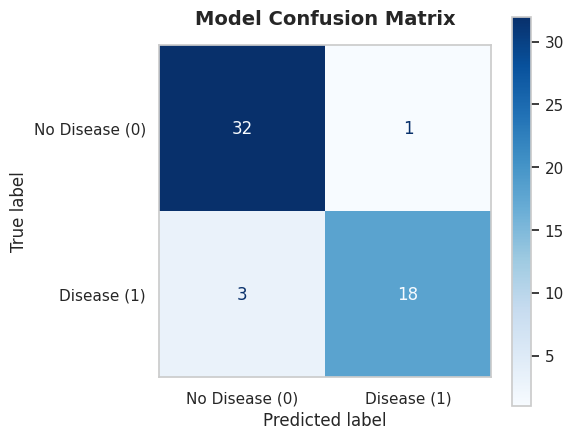

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = final_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Disease (1)'])

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Model Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.grid(False) 
plt.tight_layout()
plt.show()


In [14]:
import joblib

# This saves your 92.59% accuracy pipeline into a file named 'heart_model.pkl'
joblib.dump(final_pipeline, 'heart_model.pkl')

print("Model successfully saved as heart_model.pkl!")


Model successfully saved as heart_model.pkl!
